## **Week 2 Wednesday**
### **Topic: Encapsulation & Access Control**

**....Protecting the Inner Workings**


**Today's Journey:**
1. The Principle of Encapsulation

2. Access Modifiers: Public, Protected, Private

3. Getters & Setters: Controlled Access

4. Properties: The Pythonic Way (`@property`)

5. Class Exercise: Securing a Bank Account

6. Quiz & Best Practices

### **Objectives:**

At the end of this lesson, you will be able to:

- Explain encapsulation and why it's useful.

- Use naming conventions for public/protected/private attributes.

- Implement Getters & Setters: Controlled Access

- Implement @property with validation logic.

### **1: The Principle of Encapsulation**


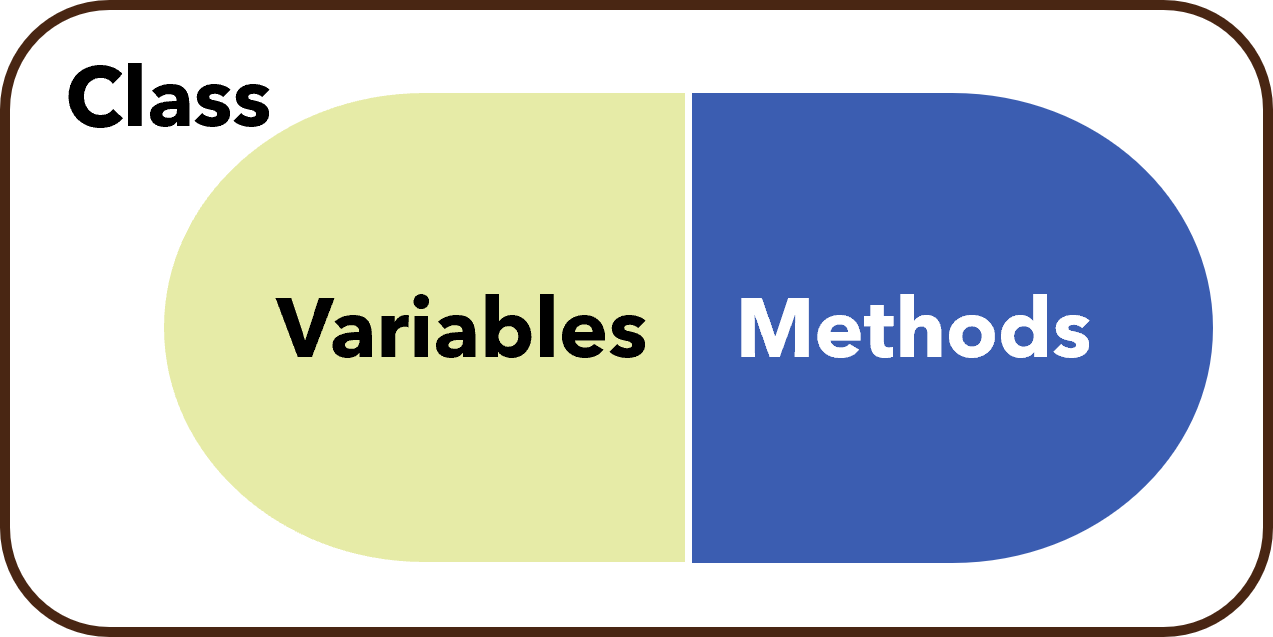


### **2. Why Encapsulation? The "Why" Behind the Lock**

### **a. Control & Validation:**
```python
# Without Encapsulation (DANGER!)
account.balance = -1000 # 😱 This breaks reality!

# With Encapsulation (SAFE!)
account.withdraw(1000) # ✅ Method validates first 
```


### **b. Maintainability:**

- You can change how the class works internally without breaking any code that uses it

- Example: Changing how you store a password (plain text -> encrypted) without affecting the ``` login() ``` method

### **c. Clear Interface:**
- Users of your class know exactly how to interact with it without needing to understand its internal workings     

- Example: You don't need to know how a car engine works to drive a car; you just use the steering wheel and pedals

### **d. Debugging & Testing:**
- Easier to track down issues when you know that certain attributes can only be changed through specific methods    





### **3. Access Modifiers in Python**
Python uses naming conventions (not strict enforcement like Java/C++)



| Modifier      | Syntax         | Meaning                                                     | Accessibility             |
|---------------|----------------|-------------------------------------------------------------|---------------------------|
| **Public**    | `variable`     | Can be accessed from anywhere                               | Inside/Outside the class  |
| **Protected** | `_variable`    | Should only be accessed within the class and its subclasses | Inside class & subclasses |
| **Private**   | `__variable`   | Should only be accessed within the class itself             | Inside the class only     |



### **4. Access Modifiers in Code**

In [ ]:
class SmartHomeDevice:
    def __init__(self, device_name):
        self.device_name = device_name             # Public attribute
        self._firmware_version = "1.0"         # Protected attribute
        self.__api_key = "secret123"           # Private attribute

    def update_firmware(self, new_version):    # Public method
        self._firmware_version = new_version   # OK to access protected

    def __connect_internally(self):            # Private method
        print(f"Using key {self.__api_key} to connect...")

device = SmartHomeDevice("living_room_light")
print(device.device_name)                        # ✅ Works
print(device._firmware_version)                # ⚠️ Works, but you shouldn't!
print(device.__api_key)                        # ❌ AttributeError!
device.__connect_internally()                  # ❌ AttributeError!

In [ ]:

class Vehicle:

    def __init__(self, make, vin_number):
        self.make = make                                 # Public attribute
        self._odometer = 0                               # Protected attribute
        self._fuel_level = 100                           # Protected attribute               
        self._miles_per_gallon = 25                      # Protected attribute
        self.__vin_number = vin_number                   # Private attribute
    

    def __calculate_fuel_required(self, distance):       # private (helper) method for internal logic only                                    
        return distance / self._miles_per_gallon

    def drive(self, distance):                           # Public method to drive the vehicle
        fuel_required = self.__calculate_fuel_required(distance)
        if fuel_required <= self._fuel_level:
            self._odometer += distance
            self._fuel_level -= fuel_required
            print(f"Successfully drove {distance} miles!")
        else:
            print("Not enough fuel to drive the distance.")

# Usage
vehicle = Vehicle("Toyota", "1HGBH41JXMN109186")

vehicle.drive(100) 
vehicle.__calculate_fuel_required

### **5: Getters and Setters (The Traditional Way)**

- Problem: We need to control how an attribute is read or written.
- Solution: Use methods to "get" and "set" the value.

In [ ]:
class Vehicle:
    def __init__(self, make, vin_number):
        self.make = make                        # Public attribute
        self._fuel_level = 100                  # Protected attribute               
        self.__vin_number = vin_number          # Private attribute
    
    # Getter for fuel level  
    def get_fuel_level(self):                   
        return self._fuel_level
  
    # Setter with integrity check
    def set_fuel_level(self, fuel_level):       
        if 0 <= fuel_level <= 100:
            self._fuel_level = fuel_level
        else: 
            print("Invalid level. Must be between 0 and 100%")
    
    # read-only access public method 
    def get_vin_number(self):                   
        return self.__vin_number
    

# Usage
vehicle = Vehicle("Honda", "123ABC456")

# Modifying protected attribute using setter
vehicle.set_fuel_level(75)

# Accessing protected attribute using getter
print(vehicle._fuel_level)      
print(vehicle.get_fuel_level()) 

# Accessing private read-only attribute using getter no setter
print(vehicle.get_vin_number()) 

In [ ]:
class BankAccount:
    def __init__(self, balance=0):
        self.__balance = balance  # Make it private

    # Getter Method
    def get_balance(self):
        print("Audit log: Balance was checked.")
        return self.__balance

    # Setter Method
    def set_balance(self, new_balance):
        if new_balance >= 0: # Validation!
            self.__balance = new_balance
        else:
            print("Error: Balance cannot be negative!")

# Usage
account = BankAccount(100)
print(account.get_balance()) # ✅ Uses getter
account.set_balance(-50)     # ❌ "Error: Balance cannot be negative!"

## Drawback: The syntax is clunky
 ``` account.get_balance() ``` instead of ```account.balance```.

### **6: Properties: The Pythonic Way (@property)**

### **Idea: Let's use the clean syntax of attribute access but with the control of methods.**

In [ ]:
class BankAccount:
    def __init__(self, balance=0):
        self.__balance = balance

    @property
    def balance(self):         # This is the GETTER
        print("Audit log: Balance was checked.")
        return self.__balance

    @balance.setter
    def balance(self, new_balance): # This is the SETTER
        if new_balance >= 0:
            self.__balance = new_balance
        else:
            raise ValueError("Balance cannot be negative!")

# Usage - Looks like attribute access, acts like method calls!
account = BankAccount(100)
print(account.balance)    # ✅ Calls the getter -> 100
account.balance = 500     # ✅ Calls the setter
account.balance = -50     # ❌ Calls setter, raises ValueError!

### **7 Class Exercise: Secure the Student Class**

**Your Mission:** Take this simple `Student` class and apply encapsulation

1. Make the `gpa` attribute **private**

2. Create a **getter** and **setter** for `gpa` using `@property`

3. **Validate** the setter: GPA must be between 0.0 and 4.0

**Starter Code:**
```python
class Student:
    def __init__(self, name, gpa):
        self.name = name
        self.gpa = gpa # We need to protect this!

# Goal: This should work
student = Student("Alice", 3.8)
print(student.gpa) # ✅ Should work
student.gpa = 4.3  # ❌ Should fail with a ValueError!

In [ ]:
## Write your code below this line



### **8: Best Practices & Pitfalls**

   **DO:** ✅ 

    - Use a single `_` for "protected" attributes for internal use

    - Use double `__` for "private" attributes you really don't want touched

    - Use `@property` for elegant getters/setters with validation or logic

   **DON'T:** ❌

    - Create getters/setters for every attribute blindly (only when you need control)

    - Overuse protected and private modifiers

    - Try to break the rules with name mangling (`_Class__privateattr`)

### **9. Quick Quiz**

**1. What is the main purpose of encapsulation?**

    a) To make code run faster

    b) To bundle data and methods while restricting access

    c) To create more classes

**2. How do you define a "private" attribute in Python?**

    a) Using the `private` keyword

    b) Prefixing it with a single underscore `_`

    c) Prefixing it with a double underscore `__`

**3. The `@property` decorator turns a method into what?**

    a) A class attribute

    b) A getter method that can be accessed like an attribute

    c) A static method


**(Answers: 1-b, 2-c, 3-b)**

### **Key Takeaways**

- **Encapsulation** is a core OOP principle for building safe, maintainable systems

- Use **Access Modifiers** (`public`, `_protected`, `__private`) to signal intent

- **Getters/Setters** control access to attributes

- **`@property`** is the Pythonic way to implement getters and setters

- Always **validate** data in your setters to protect your object's state

